<a href="https://www.kaggle.com/code/tokarserhii/practical-nn-2026-01-26?scriptVersionId=294618730" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import torch  
from torchvision import datasets, transforms 

In [2]:
data_dir = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0"

In [3]:
dataset0 = datasets.ImageFolder(data_dir)

In [4]:
len(dataset0)

3527

In [5]:
img, label = dataset0[3526]

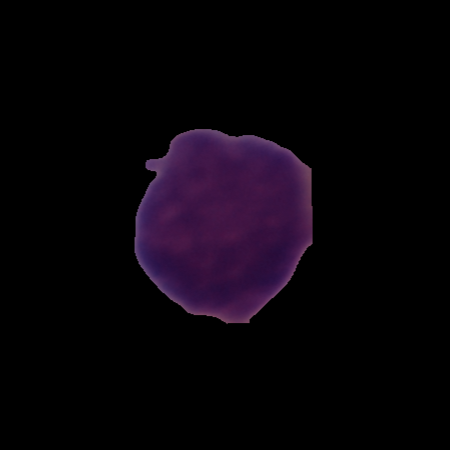

In [6]:
img

In [7]:
dataset0.classes

['all', 'hem']

In [8]:
data_dir1 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1"
dataset1 = datasets.ImageFolder(data_dir1)

data_dir2 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2"
dataset2 = datasets.ImageFolder(data_dir2)

In [9]:
dataset0.classes
dataset1.classes
dataset2.classes

['all', 'hem']

In [10]:
dataset_all = torch.utils.data.ConcatDataset([dataset0, dataset1, dataset2])

In [11]:
len(dataset_all)

10661

In [12]:
data_train, data_test = torch.utils.data.random_split(dataset_all,[0.8, 0.2])

In [13]:
len(data_train)


8529

In [14]:
len(data_test)


2132

In [15]:
img, label = data_train[5000]

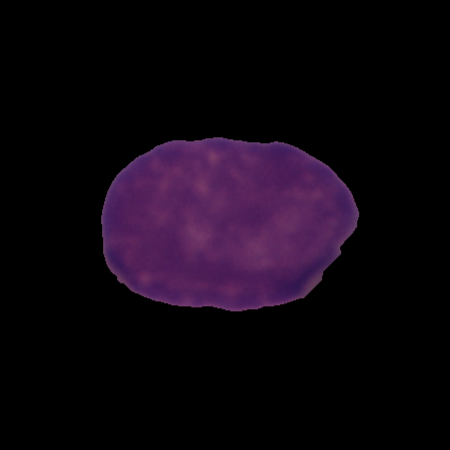

In [16]:
img

In [17]:
train_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
    transforms.CenterCrop(180),
    transforms.RandomRotation(180),
    transforms.ToTensor()
    ]
)

In [18]:
train_transform(img).shape

torch.Size([3, 180, 180])

In [19]:
test_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
    transforms.CenterCrop(180),
    transforms.ToTensor()
    ]
)

In [20]:
test_transform(img).shape

torch.Size([3, 180, 180])

In [21]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]

        new_img = self.transformer(img)
        
        return new_img, y

In [22]:
train_data = TransformDataset(data_train,train_transform)

In [23]:
test_data = TransformDataset(data_test,test_transform)

In [24]:
len(test_data)

2132

In [25]:
test_data[2100]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 0)

In [26]:
train_loader = DataLoader(train_data, batch_size=256)

In [27]:
test_loader = DataLoader(test_data, batch_size=256)


In [28]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 


torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([84, 3, 180, 180])
torch.Size([84])


(180, 180, 3)


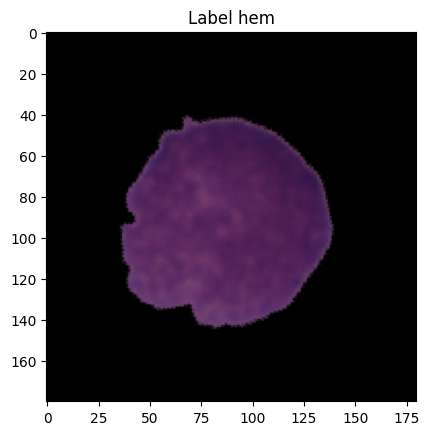

(180, 180, 3)


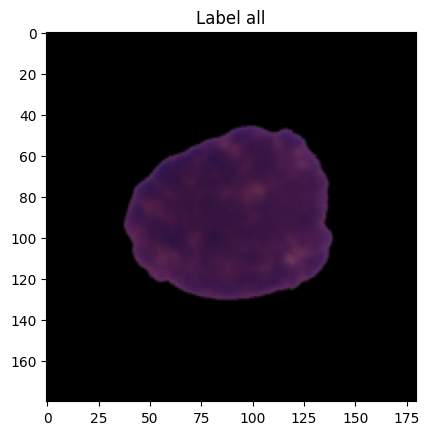

(180, 180, 3)


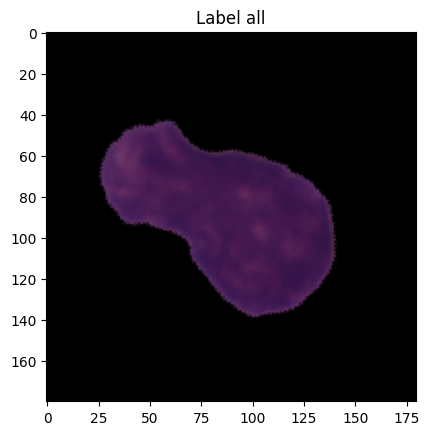

In [29]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset0.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

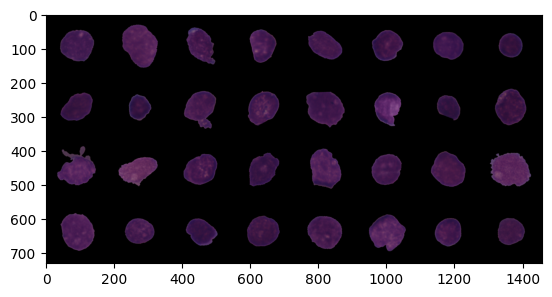

In [30]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [31]:
3*60*60

10800

In [32]:
# from torch import nn

# model = nn.Sequential(
#     nn.Flatten(),
#     nn.Linear(10800, 64),
#     nn.ReLU(),
#     nn.Linear(64, 32),
#     nn.ReLU(),
#     nn.Linear(32, 16),
#     nn.ReLU(),
#     nn.Linear(16, 2)
# )

# device = "cuda"
# model = model.to(device)

from torch import nn

model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding='same'),# розмір буде 8,180,180
    nn.ReLU(),
    nn.MaxPool2d(2,2), #8, 90 , 90
    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding='same'),#16, 90, 90
    nn.ReLU(), # 16, 90, 90
    nn.MaxPool2d(2, 2), # 16, 45, 45
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding='same'), #32, 45, 45
    nn.ReLU(), #32, 45, 45
    nn.MaxPool2d(2, 2), # 32, 22, 22

    nn.Flatten(), # 32*22*22 - 15488
    nn.Linear(15488, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

device = 'cuda'
model = model.to(device)

In [33]:
32*22*22

15488

In [34]:
for imgs, labels in train_loader:
    break

In [35]:
imgs.shape

torch.Size([256, 3, 180, 180])

In [39]:
print("model:", next(model.parameters()).device, next(model.parameters()).dtype)
imgs = imgs.to(device)
print("imgs:", imgs.device, imgs.dtype)


model: cuda:0 torch.float32
imgs: cuda:0 torch.float32


In [40]:

res = model(imgs)
res.shape

torch.Size([256, 2])

In [41]:
# функция ошибки для задачи многоклассовой классификации
loss_fn = nn.CrossEntropyLoss()

# оптимизатор Adam для обучения нейронной сети
optimizer = torch.optim.Adam(
    model.parameters(),   # параметры модели
    lr=0.001
)

# список для сохранения значений loss во время обучения
loss_list = []
loss_test_list = []

# цикл обучения по эпохам
for i in range(3):

    # перебор батчей из обучающего даталоадера
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        loss.backward()               # вычисление градиентов
        optimizer.step()              # обновление весов модели
        optimizer.zero_grad()         # очистка градиентов

        loss_list.append(loss.cpu().item())  # сохранение значения loss

    #test data
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        

        loss_test_list.append(loss.cpu().item())  # сохранение значения loss


loss: 0.677971601486206
loss: 0.6778405904769897
loss: 0.6779672503471375
loss: 0.675649106502533
loss: 0.6703258156776428
loss: 0.6801495552062988
loss: 0.675606906414032
loss: 0.6807410717010498
loss: 0.6759468913078308
loss: 0.6702109575271606
loss: 0.6754229068756104
loss: 0.6699728965759277
loss: 0.6739370822906494
loss: 0.671222984790802
loss: 0.6768428087234497
loss: 0.6695878505706787
loss: 0.6707884669303894
loss: 0.6653021574020386
loss: 0.6733256578445435
loss: 0.669863760471344
loss: 0.6663089990615845
loss: 0.6654039621353149
loss: 0.669496476650238
loss: 0.6635445952415466
loss: 0.674626886844635
loss: 0.6738302707672119
loss: 0.6730235815048218
loss: 0.6745733618736267
loss: 0.6653391122817993
loss: 0.6656396389007568
loss: 0.6690491437911987
loss: 0.6669138669967651
loss: 0.6615638732910156
loss: 0.6630517244338989
loss: 0.6667229533195496
loss: 0.6693208813667297
loss: 0.6699702739715576
loss: 0.6667229533195496
loss: 0.6589292883872986
loss: 0.6745166182518005
loss: 0

In [43]:
imgs.shape

torch.Size([81, 3, 180, 180])

In [45]:
image = torch.rand(1, 3, 180, 180)
image

tensor([[[[0.1680, 0.8709, 0.8250,  ..., 0.8696, 0.8165, 0.9313],
          [0.5259, 0.9418, 0.2718,  ..., 0.9915, 0.8081, 0.7120],
          [0.2663, 0.4692, 0.6432,  ..., 0.8327, 0.3888, 0.2733],
          ...,
          [0.5929, 0.7415, 0.7711,  ..., 0.8094, 0.4697, 0.7639],
          [0.6179, 0.2268, 0.7041,  ..., 0.6728, 0.8731, 0.2731],
          [0.7378, 0.9846, 0.7260,  ..., 0.4600, 0.4693, 0.4718]],

         [[0.9670, 0.9462, 0.9966,  ..., 0.7612, 0.9026, 0.1496],
          [0.2511, 0.4632, 0.5320,  ..., 0.1175, 0.3759, 0.0211],
          [0.7442, 0.9923, 0.6135,  ..., 0.8321, 0.0801, 0.4994],
          ...,
          [0.7311, 0.5669, 0.4501,  ..., 0.0077, 0.3417, 0.9141],
          [0.9130, 0.4195, 0.4293,  ..., 0.8525, 0.3557, 0.2461],
          [0.6882, 0.8685, 0.8452,  ..., 0.7747, 0.9491, 0.1568]],

         [[0.6090, 0.9964, 0.4159,  ..., 0.9308, 0.3727, 0.8419],
          [0.0846, 0.1094, 0.2853,  ..., 0.2810, 0.5031, 0.7843],
          [0.6031, 0.4946, 0.7465,  ..., 0

In [48]:
model = model.to('cpu')
torch.onnx.export(
    model,
    image,
    'leukemia.onnx',
    input_names = ["input"],
    output_names = ["output"]
    )

/tmp/ipykernel_55/3474716214.py:2: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


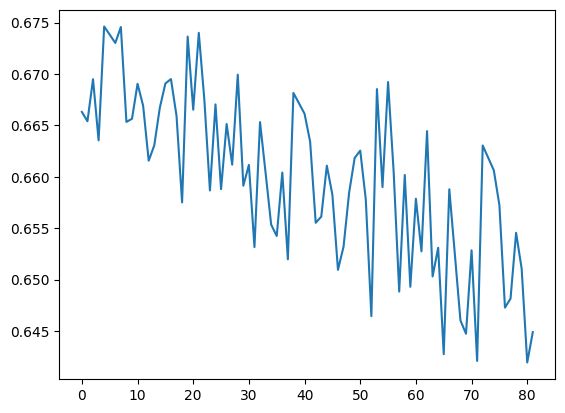

In [42]:
import matplotlib.pyplot as plt

new_list = loss_list[20 :]

plt.plot(new_list)



In [ ]:
plt.plot(loss_test_list)

In [ ]:
imgs.shape

In [ ]:
img, label = train_data[100]
img = img.unsqueeze(0)
img.shape

In [ ]:
img = img.to(device)
prediction = model(img)
print(label)
print(nn.Softmax()(prediction))

In [ ]:
result = model(imgs)

In [ ]:
res1 = result.argmax(dim=1)

In [ ]:
labels

In [ ]:
res2 = res1 == labels

In [ ]:
res2.sum()

In [ ]:
67/81

In [ ]:
count = 0



for imgs, labels in train_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)
    res = model(imgs)
    res = res.argmax(dim=1)
    res2 = res == labels
    summa = res2.sum()
    count += summa.cpu().item()

print(count) 

In [ ]:
len(train_data) 

In [ ]:
6829/8529